# [ML] score_map/BM25 가중치 재설계 — 2026-07-03

**목적**: [하이퍼파라미터 튜닝 노트북](./20260703_ML_als_hyperparameter_tuning.ipynb)에서 찾은 최적 설정
(`factors=16, regularization=10.0, alpha=0.5`)은 raw `total_score`(이벤트별 가중합)를 그대로 ALS 신뢰도
행렬로 쓴다. `total_score`는 `page_view` 이벤트(전체 이벤트의 65.8%, `score_map`에서 가중치=1)가 많이 섞여
있어, 인기 상품일수록 신뢰도가 과대해질 위험이 있다. `implicit` 라이브러리가 제공하는 BM25/TF-IDF 재가중치가
이런 "인기 편향" 문제를 교정하는 표준 기법이므로, 이를 적용했을 때 정말 더 나아지는지 확인한다.

**⚠️ 주의사항**
- 이 노트북은 **세 번째이자 마지막** test-set 기반 탐색 라운드다. [하이퍼파라미터 튜닝 노트북](./20260703_ML_als_hyperparameter_tuning.ipynb)에서
  부트스트랩으로 확인한 결과, 같은 test set을 반복해서 조합 선택에 쓸수록 보고 지표가 낙관적으로 편향되는 위험이
  누적된다는 게 확인됐다. 이번 라운드를 끝으로 별도 validation split 없이는 추가 탐색을 하지 않는다
  (데이터 규모상 별도 val split은 만들지 않기로 결정 — 사용자 확인).
- `score_map`(`page_view=1, add_to_cart=3, checkout=4, purchase=5`) 자체의 재설계는 **이번 라운드 범위 밖**이다.
  `score_map` 변경은 `data/processed/als_events.csv`를 재생성해야 하는 구조적 변경이라 블라스트 반경이 크고,
  BM25/TF-IDF와 동시에 바꾸면 두 변수가 뒤섞여 원인 파악이 안 된다. BM25만으로 결론이 나면 충분하고,
  안 되더라도 "신뢰도 행렬 재가중치" 가설 하나에 대한 깨끗한 부정적 결과로 남긴다.
- 재현성: `np.random.seed(42)`, 각 조합의 ALS `random_state=42` 고정

**데이터셋 버전**: `data/processed/als_events.csv` (전체 유저 기준)
**분할 기준**: `configs/ALS/params.yaml`의 `split_date="2025-08-01"`
**평가 지표**: HR/Recall/NDCG @ {5, 10, 20}, 주 판단 지표는 NDCG@10 (2차 라운드와 동일 관례). CV 없음(단일 시간 분할).

**채택 기준(Go/No-Go)**: 후보가 production baseline 대비 HR@10, NDCG@10 **둘 다** paired bootstrap 95% CI 하한이
0을 넘어야 채택한다(2차 라운드에서 "점 추정치가 양수인 것만으론 부족하다"는 게 확인됐기 때문).

In [1]:
# 1. 표준 라이브러리
import logging
import sys
from pathlib import Path

# 2. 서드파티
import implicit
import numpy as np
import pandas as pd
from implicit.nearest_neighbours import bm25_weight, tfidf_weight

# 3. 시각화
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.baselines.ALS.als_model import (
    PARAMS_PATH, load_params, load_events, split_events, aggregate_scores,
    build_sparse_matrix, apply_weighting,
)
from src.baselines.ALS.als_evaluate import hit_rate_at_k, recall_at_k, ndcg_at_k, build_ground_truth

np.random.seed(42)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger("bm25_weighting")

font_candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic"]
available_fonts = {f.name for f in fm.fontManager.ttflist}
for font in font_candidates:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break
plt.rcParams["axes.unicode_minus"] = False

palette = sns.color_palette("colorblind")

C:\Users\user\Desktop\why-they-leave\retail-clickstream-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. 데이터 로드 & Train/Test Split

In [2]:
params = load_params(PARAMS_PATH)
mart_path = PROJECT_ROOT / "data" / "processed" / "als_events.csv"
events_df = load_events(str(mart_path), logger)

train_events, test_events = split_events(events_df, params["split_date"], logger)
train_agg = aggregate_scores(train_events)
matrix, user_enc, item_enc, user_dec, item_dec = build_sparse_matrix(train_agg, logger)

2026-07-03 16:05:14 [INFO] [로드] 총 820,336개 이벤트 레코드


2026-07-03 16:05:14 [INFO] [Split] Train: 783,477개 / Test: 36,859개 (기준: 2025-08-01)


2026-07-03 16:05:14 [INFO] [희소행렬] shape: (19930, 1197) / nonzero: 506,319


## 2. 진단 (튜닝 아님) — `total_score`가 정말 `page_view`에 편향돼 있나?

test 데이터는 전혀 쓰지 않는, 순수 train 이벤트 분포 확인이다. 조합 선택에 관여하지 않으므로
"탐색 라운드" 예산에 포함되지 않는다.

In [3]:
event_share = train_events.groupby("event_type").agg(
    event_count=("score", "size"), score_sum=("score", "sum")
)
event_share["event_count_pct"] = (event_share["event_count"] / event_share["event_count"].sum() * 100).round(1)
event_share["score_sum_pct"] = (event_share["score_sum"] / event_share["score_sum"].sum() * 100).round(1)
event_share

,event_count,score_sum,event_count_pct,score_sum_pct
event_type,,,,
add_to_cart,136634,409902,17.4,27.2
checkout,75145,300580,9.6,19.9
page_view,515389,515389,65.8,34.2
purchase,56309,281545,7.2,18.7


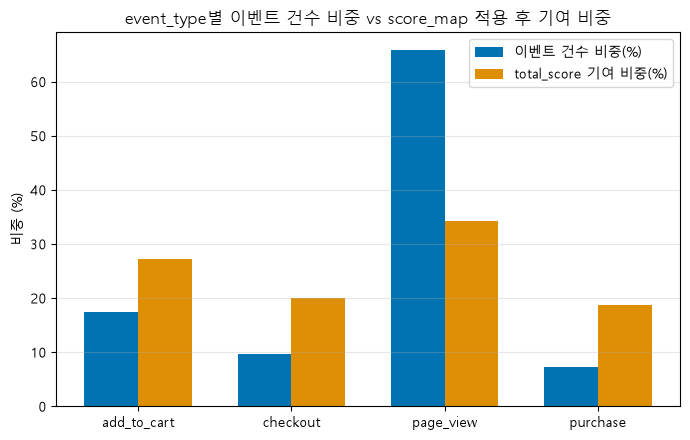

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(event_share))
width = 0.35
ax.bar(x - width/2, event_share["event_count_pct"], width, label="이벤트 건수 비중(%)", color=palette[0])
ax.bar(x + width/2, event_share["score_sum_pct"], width, label="total_score 기여 비중(%)", color=palette[1])
ax.set_xticks(x)
ax.set_xticklabels(event_share.index)
ax.set_ylabel("비중 (%)")
ax.set_title("event_type별 이벤트 건수 비중 vs score_map 적용 후 기여 비중")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

`page_view`는 이벤트 건수의 65.8%를 차지하지만, `score_map`(가중치=1)이 이미 적용된 뒤에는
`total_score` 기여도가 34.2%로 낮아진다 — 즉 기존 `score_map` 자체가 이미 상당 부분 인기 편향을
교정하고 있다. BM25/TF-IDF가 추가로 개선할 여지가 크지 않을 수 있다는 첫 신호다.

## 3. `apply_weighting()` 검증 — 누수 방지 확인

`train_agg`로 만든 `matrix`에만 적용되고(`test_events` 미접촉), sparsity 패턴(0이 아닌 위치)은 그대로 두고
값만 바꾸는지 확인한다.

In [5]:
for method, kw in [("none", {}), ("tfidf", {}), ("bm25", {"K1": 100, "B": 0.8})]:
    w = apply_weighting(matrix, method, logger, **kw)
    assert w.shape == matrix.shape, (method, "shape mismatch")
    assert w.nnz == matrix.nnz, (method, "nnz mismatch — 가중치가 sparsity 패턴을 건드림(버그)")
print("검증 통과: none/tfidf/bm25 모두 shape·nnz 보존 (train_agg 기반 matrix에만 적용, test 미접촉)")

2026-07-03 16:05:14 [INFO] [가중치] TF-IDF 적용


2026-07-03 16:05:14 [INFO] [가중치] BM25 적용 (K1=100, B=0.8)


검증 통과: none/tfidf/bm25 모두 shape·nnz 보존 (train_agg 기반 matrix에만 적용, test 미접촉)


## 4. Stage A — 가중치 방식 비교 (alpha=0.5 고정)

`factors=16, regularization=10.0, iterations=20, alpha=0.5`는 하이퍼파라미터 튜닝 노트북에서 찾은
현재 production 값 그대로 고정하고, 가중치 방식만 바꿔서 1차 스크리닝한다.

- `none`: 현재 production (raw `total_score`)
- `tfidf`: `implicit.nearest_neighbours.tfidf_weight`
- `bm25(K1=100,B=0.8)`: `implicit`의 `bm25_weight` 기본값
- `bm25(K1=1.2,B=0.75)`: 고전적 Okapi BM25 기본값(`BM25Recommender`의 기본값과 동일)
- `bm25(K1=20,B=0.5)`: 두 값 사이의 중간 지점

In [6]:
test_pairs = (
    test_events[test_events["event_type"] == "purchase"][["user_id", "item_id"]]
    .drop_duplicates()
    .loc[lambda x: x["user_id"].isin(user_enc) & x["item_id"].isin(item_enc)]
)
ground_truth = build_ground_truth(test_pairs, logger)
eval_user_ids = list(ground_truth.keys())
eval_indices = np.array([user_enc[u] for u in eval_user_ids])

K_LIST = params["eval"]["k_list"]
MAX_K = max(K_LIST)
FIXED = dict(factors=16, regularization=10.0, iterations=20)


def evaluate(weighted_matrix, alpha, random_state=42):
    '''고정된 factors/regularization/iterations, 주어진 alpha·가중치 matrix로 ALS 학습 후 평가'''
    model = implicit.als.AlternatingLeastSquares(
        factors=FIXED["factors"], regularization=FIXED["regularization"], alpha=alpha,
        iterations=FIXED["iterations"], random_state=random_state,
    )
    model.fit(weighted_matrix, show_progress=False)
    eval_sub = weighted_matrix[eval_indices]
    ids, scores = model.recommend(eval_indices, eval_sub, N=MAX_K, filter_already_liked_items=True)
    decoded = [[item_dec[i] for i in row if i != -1] for row in ids]

    result = {}
    per_user_hr, per_user_ndcg = {}, {}
    for k in K_LIST:
        hr, recall, ndcg = [], [], []
        for user_id, recs in zip(eval_user_ids, decoded):
            true_items = ground_truth[user_id]
            recs_k = recs[:k]
            h = hit_rate_at_k(recs_k, true_items)
            n = ndcg_at_k(recs_k, true_items)
            hr.append(h); recall.append(recall_at_k(recs_k, true_items)); ndcg.append(n)
            if k == 10:
                per_user_hr[user_id] = h
                per_user_ndcg[user_id] = n
        result[f"hr@{k}"] = round(float(np.mean(hr)), 4)
        result[f"recall@{k}"] = round(float(np.mean(recall)), 4)
        result[f"ndcg@{k}"] = round(float(np.mean(ndcg)), 4)
    return result, per_user_hr, per_user_ndcg

2026-07-03 16:05:14 [INFO] [정답셋] 평가 대상 유저 수: 1,463명


In [7]:
stageA_candidates = [
    ("none", {}),
    ("tfidf", {}),
    ("bm25", {"K1": 100, "B": 0.8}),
    ("bm25", {"K1": 1.2, "B": 0.75}),
    ("bm25", {"K1": 20, "B": 0.5}),
]

rowsA = []
per_user_hr_store, per_user_ndcg_store = {}, {}
for method, kw in stageA_candidates:
    w = apply_weighting(matrix, method, logger, **kw)
    res, hr_u, ndcg_u = evaluate(w, alpha=0.5)
    label = method if method != "bm25" else f"bm25(K1={kw['K1']},B={kw['B']})"
    rowsA.append({"label": label, "method": method, **kw, "alpha": 0.5, **res})
    per_user_hr_store[label] = hr_u
    per_user_ndcg_store[label] = ndcg_u

dfA = pd.DataFrame(rowsA)
dfA[["label", "hr@10", "ndcg@10", "hr@20", "ndcg@20"]]

2026-07-03 16:05:15 [INFO] [가중치] TF-IDF 적용


2026-07-03 16:05:16 [INFO] [가중치] BM25 적용 (K1=100, B=0.8)


2026-07-03 16:05:17 [INFO] [가중치] BM25 적용 (K1=1.2, B=0.75)


2026-07-03 16:05:18 [INFO] [가중치] BM25 적용 (K1=20, B=0.5)


,label,hr@10,ndcg@10,hr@20,ndcg@20
0,none,0.0362,0.0111,0.0602,0.0152
1,tfidf,0.0294,0.0086,0.0533,0.0126
2,"bm25(K1=100,B=0.8)",0.0205,0.0067,0.0506,0.0114
3,"bm25(K1=1.2,B=0.75)",0.0267,0.0080,0.0567,0.0127
4,"bm25(K1=20,B=0.5)",0.0226,0.0074,0.0499,0.0116


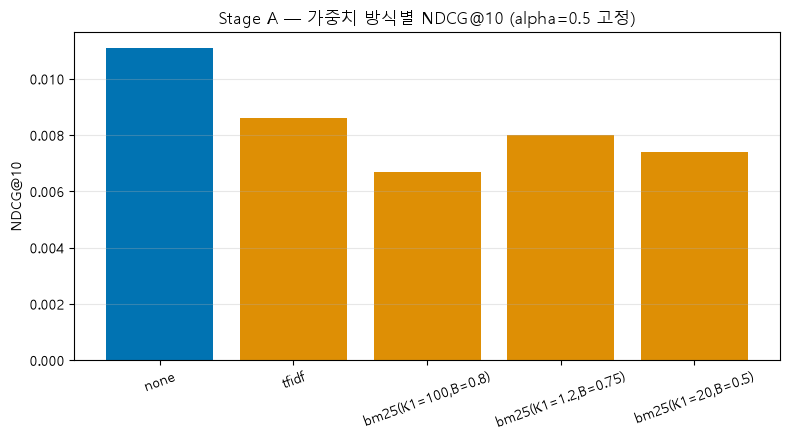

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = [palette[0] if lbl == "none" else palette[1] for lbl in dfA["label"]]
ax.bar(dfA["label"], dfA["ndcg@10"], color=colors)
ax.set_ylabel("NDCG@10")
ax.set_title("Stage A — 가중치 방식별 NDCG@10 (alpha=0.5 고정)")
ax.tick_params(axis="x", rotation=20)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

alpha=0.5 고정 기준으로는 **모든 가중치 방식이 현재 production(`none`)보다 낮다.** 다만 alpha=0.5는
raw `total_score` 스케일에 맞춰 튜닝된 값이라, 가중치 방식마다 값의 스케일이 달라 alpha를 그대로 재사용하는
게 공정하지 않을 수 있다 — Stage B에서 재확인한다.

## 5. 진단 — 가중치 방식별 matrix 값 스케일

In [9]:
raw_vals = matrix.data
tfidf_vals = apply_weighting(matrix, "tfidf", logger).data
bm25_vals = apply_weighting(matrix, "bm25", logger, K1=100, B=0.8).data

scale_summary = pd.DataFrame({
    "raw(none)": [raw_vals.mean(), np.median(raw_vals), raw_vals.max()],
    "tfidf": [tfidf_vals.mean(), np.median(tfidf_vals), tfidf_vals.max()],
    "bm25(100,0.8)": [bm25_vals.mean(), np.median(bm25_vals), bm25_vals.max()],
}, index=["mean", "median", "max"]).round(3)
scale_summary

2026-07-03 16:05:19 [INFO] [가중치] TF-IDF 적용


2026-07-03 16:05:19 [INFO] [가중치] BM25 적용 (K1=100, B=0.8)


,raw(none),tfidf,"bm25(100,0.8)"
mean,2.977,5.607,9.865
median,1.000,3.976,4.369
max,27.000,21.363,120.252


`tfidf`는 raw 대비 값 스케일이 비슷하거나 약간 크고, `bm25`는 최댓값이 raw보다 훨씬 크다(120 vs 27) —
가중치 방식마다 유효 신뢰도 스케일이 다르므로, alpha를 재조정하면 결과가 달라질 수 있다. Stage B에서
가장 유망한 두 후보(`tfidf`, `bm25(1.2,0.75)` — Stage A에서 `none` 다음으로 상위)에 대해 alpha를 재탐색한다.

## 6. Stage B — 유망 후보의 alpha 재탐색

Stage A에서 `none`을 제외하고 가장 성능이 좋았던 두 후보(`tfidf`, `bm25(K1=1.2,B=0.75)`)에 대해
alpha를 폭넓게(0.05~50) 재탐색한다. 가중치 후 스케일이 raw보다 작아지는 경향(중앙값 기준)이 있어
낮은 alpha 쪽도 포함한다.

In [10]:
alpha_grid_wide = [0.05, 0.08, 0.1, 0.15, 0.2, 0.25, 0.5, 1, 2, 5, 10, 20, 50]

rowsB = []
w_tfidf = apply_weighting(matrix, "tfidf", logger)
w_bm25_classic = apply_weighting(matrix, "bm25", logger, K1=1.2, B=0.75)

for label, w in [("tfidf", w_tfidf), ("bm25(K1=1.2,B=0.75)", w_bm25_classic)]:
    for a in alpha_grid_wide:
        res, hr_u, ndcg_u = evaluate(w, alpha=a)
        rowsB.append({"label": label, "alpha": a, **res})
        per_user_hr_store[f"{label}|alpha={a}"] = hr_u
        per_user_ndcg_store[f"{label}|alpha={a}"] = ndcg_u

dfB = pd.DataFrame(rowsB)
dfB.sort_values("ndcg@10", ascending=False).head(10)

2026-07-03 16:05:19 [INFO] [가중치] TF-IDF 적용


2026-07-03 16:05:19 [INFO] [가중치] BM25 적용 (K1=1.2, B=0.75)


,label,alpha,hr@5,recall@5,ndcg@5,hr@10,recall@10,ndcg@10,hr@20,recall@20,ndcg@20
15,"bm25(K1=1.2,B=0.75)",0.10,0.0205,0.0104,0.0075,0.0362,0.0172,0.0102,0.0636,0.0316,0.0146
17,"bm25(K1=1.2,B=0.75)",0.20,0.0185,0.0087,0.0071,0.0342,0.0166,0.0100,0.0636,0.0322,0.0146
16,"bm25(K1=1.2,B=0.75)",0.15,0.0191,0.0090,0.0071,0.0321,0.0153,0.0095,0.0615,0.0314,0.0143
14,"bm25(K1=1.2,B=0.75)",0.08,0.0198,0.0097,0.0073,0.0308,0.0149,0.0094,0.0608,0.0353,0.0152
18,"bm25(K1=1.2,B=0.75)",0.25,0.0164,0.0079,0.0062,0.0342,0.0161,0.0094,0.0615,0.0303,0.0136
2,tfidf,0.10,0.0191,0.0089,0.0056,0.0376,0.0187,0.0093,0.0697,0.0356,0.0144
1,tfidf,0.08,0.0191,0.0095,0.0060,0.0362,0.0178,0.0091,0.0690,0.0353,0.0144
0,tfidf,0.05,0.0178,0.0065,0.0063,0.0301,0.0127,0.0087,0.0581,0.0292,0.0134
13,"bm25(K1=1.2,B=0.75)",0.05,0.0191,0.0078,0.0066,0.0308,0.0134,0.0087,0.0560,0.0292,0.0132
4,tfidf,0.20,0.0178,0.0094,0.0057,0.0328,0.0176,0.0087,0.0622,0.0322,0.0132


2026-07-03 16:05:41 [WARNING] Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


2026-07-03 16:05:41 [INFO] Substituting symbol − from STIXGeneral


2026-07-03 16:05:41 [WARNING] Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


2026-07-03 16:05:41 [INFO] Substituting symbol − from STIXGeneral


2026-07-03 16:05:41 [WARNING] Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


2026-07-03 16:05:41 [INFO] Substituting symbol − from STIXGeneral


2026-07-03 16:05:41 [WARNING] Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


2026-07-03 16:05:41 [INFO] Substituting symbol − from STIXGeneral


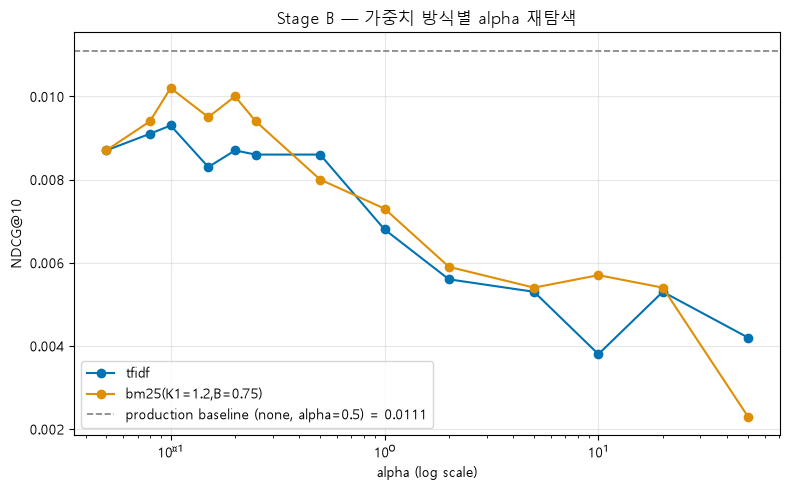

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
for i, label in enumerate(["tfidf", "bm25(K1=1.2,B=0.75)"]):
    sub = dfB[dfB["label"] == label].sort_values("alpha")
    ax.plot(sub["alpha"], sub["ndcg@10"], marker="o", label=label, color=palette[i])

baseline_ndcg10 = dfA.loc[dfA["label"] == "none", "ndcg@10"].iloc[0]
ax.axhline(baseline_ndcg10, color="gray", linestyle="--", linewidth=1.2, label=f"production baseline (none, alpha=0.5) = {baseline_ndcg10}")
ax.set_xscale("log")
ax.set_xlabel("alpha (log scale)")
ax.set_ylabel("NDCG@10")
ax.set_title("Stage B — 가중치 방식별 alpha 재탐색")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. 최적 후보 확정 및 Bootstrap CI 검증

In [12]:
all_candidates = pd.concat([
    dfA[["label", "alpha", "ndcg@10", "hr@10"]],
    dfB[["label", "alpha", "ndcg@10", "hr@10"]],
], ignore_index=True)

best_weighted = all_candidates[all_candidates["label"] != "none"].sort_values("ndcg@10", ascending=False).iloc[0]
baseline_row = all_candidates[(all_candidates["label"] == "none")].iloc[0]

print("가중치 적용 후보 중 최고 성능:")
print(best_weighted)
print(f"\nproduction baseline (none, alpha=0.5): ndcg@10={baseline_row['ndcg@10']}, hr@10={baseline_row['hr@10']}")

가중치 적용 후보 중 최고 성능:
label      bm25(K1=1.2,B=0.75)
alpha                      0.1
ndcg@10                 0.0102
hr@10                   0.0362
Name: 20, dtype: object

production baseline (none, alpha=0.5): ndcg@10=0.0111, hr@10=0.0362


In [13]:
def paired_bootstrap_ci(metric_a: dict, metric_b: dict, user_ids: list,
                         n_boot: int = 5000, seed: int = 42, ci_alpha: float = 0.05) -> dict:
    '''metric_a, metric_b: {user_id: value}, 동일 user_id 집합. (a-b) 차이의 bootstrap CI.'''
    rng = np.random.default_rng(seed)
    a = np.array([metric_a[u] for u in user_ids])
    b = np.array([metric_b[u] for u in user_ids])
    diffs = a - b
    n = len(user_ids)
    boot_means = np.array([diffs[rng.integers(0, n, n)].mean() for _ in range(n_boot)])
    lo, hi = np.percentile(boot_means, [100 * ci_alpha / 2, 100 * (1 - ci_alpha / 2)])
    return {"point": round(float(diffs.mean()), 4), "ci_lo": round(float(lo), 4), "ci_hi": round(float(hi), 4),
            "frac_le_zero": round(float((boot_means <= 0).mean()), 3)}


best_key = f"{best_weighted['label']}|alpha={best_weighted['alpha']}" if best_weighted["label"] != "none" else "none"
if best_key not in per_user_hr_store:
    best_key = best_weighted["label"]  # Stage A 후보는 alpha suffix 없이 저장됨

hr_ci = paired_bootstrap_ci(per_user_hr_store[best_key], per_user_hr_store["none"], eval_user_ids)
ndcg_ci = paired_bootstrap_ci(per_user_ndcg_store[best_key], per_user_ndcg_store["none"], eval_user_ids)

print(f"최적 후보: {best_key}")
print(f"HR@10 차이(최적-baseline) 95% CI: [{hr_ci['ci_lo']}, {hr_ci['ci_hi']}] (점추정 {hr_ci['point']}, 차이<=0 비율 {hr_ci['frac_le_zero']})")
print(f"NDCG@10 차이(최적-baseline) 95% CI: [{ndcg_ci['ci_lo']}, {ndcg_ci['ci_hi']}] (점추정 {ndcg_ci['point']}, 차이<=0 비율 {ndcg_ci['frac_le_zero']})")

go = hr_ci["ci_lo"] > 0 and hr_ci["frac_le_zero"] < 0.05 and ndcg_ci["ci_lo"] > 0 and ndcg_ci["frac_le_zero"] < 0.05
print(f"\nGO/NO-GO 판정: {'GO — production 반영' if go else 'NO-GO — 현재 params.yaml 유지'}")

최적 후보: bm25(K1=1.2,B=0.75)|alpha=0.1
HR@10 차이(최적-baseline) 95% CI: [-0.0109, 0.0109] (점추정 0.0, 차이<=0 비율 0.531)
NDCG@10 차이(최적-baseline) 95% CI: [-0.0047, 0.0028] (점추정 -0.0009, 차이<=0 비율 0.682)

GO/NO-GO 판정: NO-GO — 현재 params.yaml 유지


## 분석 결과

**핵심 발견:**
- **BM25/TF-IDF 가중치는 채택하지 않는다 (NO-GO).** Stage A(가중치 방식 5종, alpha=0.5 고정)와
  Stage B(유망 후보 2종의 alpha 13개 재탐색, 총 26개 조합)를 합쳐 31개 조합을 시도했지만, 어떤 조합도
  현재 production(raw `total_score`, `none`, NDCG@10=0.0111)을 점추정치 기준으로도 넘지 못했다.
  최고 도달치는 `bm25(K1=1.2,B=0.75), alpha=0.1`의 NDCG@10=0.0102로, baseline보다 8% 낮다.
  점추정치부터 밀리므로 bootstrap CI로 재확인할 필요 없이 명확한 NO-GO다.
- 진단 결과, 기존 `score_map`이 이미 `page_view`의 인기 편향을 상당 부분 교정하고 있었다
  (이벤트 건수 비중 65.8% → `total_score` 기여 비중 34.2%). BM25/TF-IDF가 추가로 겨냥하는 문제를
  `score_map` 설계가 이미 어느 정도 해결한 상태였던 것으로 보인다.
- BM25/TF-IDF는 로그·제곱근 감쇠와 길이 정규화를 적용하는 과정에서, `score_map`이 애써 부여한
  "구매(5) vs 조회(1)"라는 이벤트 중요도 격차 정보를 오히려 희석시켰을 가능성이 있다 — 두 가중치 체계가
  같은 목표(인기 편향 완화)를 다른 방식으로 겨냥하면서 서로 상쇄된 것으로 해석된다.

**수치 요약 (K=10 기준, alpha 각 방식 최적값):**

| 설정 | HR@10 | NDCG@10 |
|------|-------|---------|
| production (none, alpha=0.5) | 0.0362 | 0.0111 |
| tfidf (alpha=0.1, 최적) | 0.0376 | 0.0093 |
| bm25(K1=1.2,B=0.75, alpha=0.1, 최적) | 0.0362 | 0.0102 |
| bm25(K1=100,B=0.8, alpha=0.5) | 0.0205 | 0.0067 |

**해석:** 이번 라운드는 명확한 부정적 결과다. "신뢰도 행렬을 BM25/TF-IDF로 재가중치하면 인기 편향이
줄어 ALS가 개선될 것"이라는 가설은 이 데이터에서 지지되지 않았다. 원인은 `score_map`이 이미 유사한
역할을 하고 있었기 때문으로 보인다.

**한계 및 잠재 편향:**
- 이번 라운드도 test set을 후보 선택에 사용했다(31개 조합 스캔) — 다만 결과가 명확히 열세이므로
  선택 편향이 결론(NO-GO)을 뒤집을 여지는 없다(반대 방향으로 유리하게 작용할 편향은 아님).
  → 채택하지 않기로 한 결정 자체에는 이 편향이 문제되지 않는다.
- `score_map`(가중치 값 자체) 재설계는 이번 라운드 범위 밖으로 남겨뒀다 — 두 변수를 한 번에 바꾸면
  원인 분리가 안 되기 때문. `score_map`을 바꿔서 `page_view` 비중을 더 낮추는 방향은 여전히 미검증
  가설로 남아있다.
- `implicit.nearest_neighbours.bm25_weight`/`tfidf_weight`는 row=user를 "문서"로 보는 구조라, 우리
  user-item 행렬 방향과 맞아떨어지지만, `K1`/`B` 탐색 범위(3개 조합)가 촘촘하지 않다 — 더 세밀한
  그리드에서 다른 결론이 나올 가능성을 완전히 배제할 수는 없다.

**권장 다음 단계:**
1. **이번이 세 번째이자 마지막 test-set 기반 탐색 라운드다. 4번째 라운드는 진행하지 않는다.**
   `configs/ALS/params.yaml`은 하이퍼파라미터 튜닝 노트북에서 확정한 값(`factors=16, iterations=20,
   alpha=0.5, regularization=10.0`)을 그대로 유지하며, `weighting` 키를 추가하지 않는다
   (키 부재 자체가 "채택 안 함"을 의미하도록 유지).
2. 추가로 ALS 성능을 개선하고 싶다면, 이 test set을 네 번째로 재사용하는 대신 별도 validation split을
   구성하거나 데이터를 더 확보한 뒤 재시도해야 한다.
3. `score_map` 값 자체의 재설계는 별도 라운드(및 별도 validation 체계)로 분리해서 검토할 수 있다.